## EDA Introduction
Going into EDA, the goal was to understand what the data actually looked like: the distributions of legitimate vs fraudulent transactions, whether any features had strong discriminating power between classes, and how much overlap existed across the feature space. To quantify separation, I applied correlation analysis and Cohen's d effect size measurements per feature.
What emerged was that no single feature cleanly separates the two classes, as overlap exists everywhere. However, the nature of the overlap was revealing. Legitimate transactions cluster tightly and nearly symmetrically around zero across most features. Fraudulent transactions are far more dispersed and multimodal, suggesting that fraud does not follow a single pattern. This led to comparing feature pairs rather than individual features, looking for combinations that might reveal structure invisible in isolation.

In [16]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("../fraud.db")
df = pd.read_sql("""
    SELECT * 
    FROM transactions
""", conn)

def run_query(query):
    return pd.read_sql(query, conn)

In [37]:
amounts = run_query("""
    SELECT Class,
    AVG(Amount) AS mean_amount,
    SUM((Amount - mean_amount) * (Amount - mean_amount)) / (COUNT(*) - 1) AS Variance
    FROM (
        SELECT 
            Class,
            Amount,
            AVG(Amount) OVER (PARTITION BY Class) AS mean_amount
        FROM transactions
    )
    GROUP BY Class;
""")

conn.close()

amounts["StdDev"] = np.sqrt(amounts["Variance"])
amounts

,Class,mean_amount,Variance,StdDev
0,0,88.291022,62552.557157,250.105092
1,1,122.211321,65886.310491,256.683288


In [20]:
df.groupby("Class")["Amount"].skew()

Class
0    17.003147
1     3.754477
Name: Amount, dtype: float64

In [21]:
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

summary = df.groupby("Class")["Amount"].agg([
    "mean",
    "median",
    "std",
    "skew",
    iqr
])

summary

,mean,median,std,skew,iqr
Class,,,,,
0,88.291022,22.00,250.105092,17.003147,71.40
1,122.211321,9.25,256.683288,3.754477,104.89


## Basic Statistical Summary

Normal transactions exhibit lower variance and a tighter interquartile range, indicating more consistent structure in the transformed feature space. Fraudulent transactions appear more dispersed across the feature space, suggesting less consistent structure.

Due to the extreme class imbalance, differences in skewness should be treated as directional indicators rather than definitive findings, as small sample effects and outliers in the fraud class can distort distributional statistics.

The following sections examine time-based fraud patterns first, then move into the PCA feature space to assess class dispersion and separability across individual components and feature pairs.

### Fraudulent Activity Time Analysis

The time analysis examined fraud and legitimate transaction rates across the full 48-hour period captured in the dataset. A clear cyclic pattern emerged, with fraudulent activity peaking around the same time each day, presumably in the early morning hours. Notably, these spikes in fraud corresponded with periods of lower legitimate transaction volume, suggesting that fraudulent activity may be deliberately targeted toward low-traffic windows where anomalies are less likely to be flagged.
Because of this cyclic pattern, Time was retained as a feature for model training rather than dropped. A flat distribution would have justified removing it, but the observed periodicity carries predictive signal worth preserving.

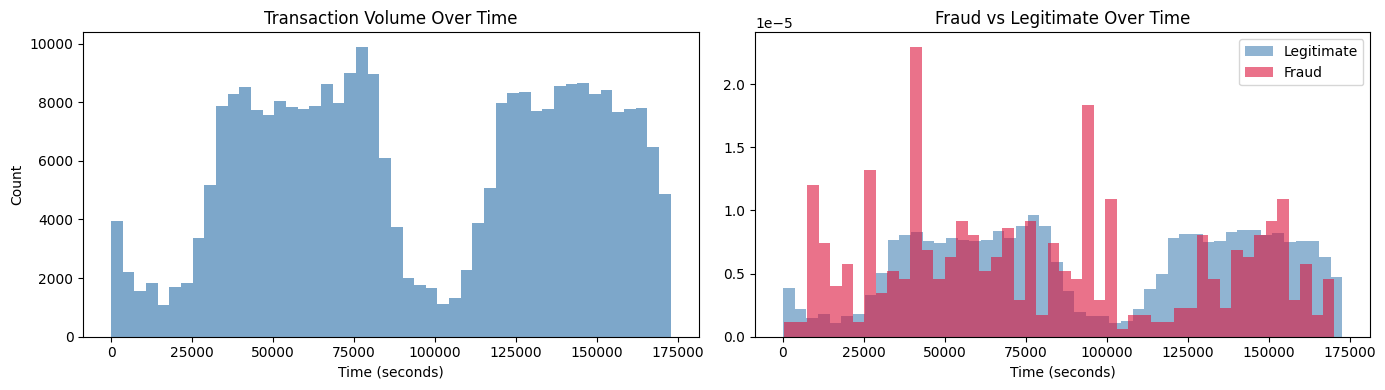

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# All transactions over time
axes[0].hist(df['Time'], bins=48, color='steelblue', alpha=0.7)
axes[0].set_title('Transaction Volume Over Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')

# Fraud vs non-fraud over time
axes[1].hist(df[df['Class']==0]['Time'], bins=48, 
             density=True,
             alpha=0.6, color='steelblue', label='Legitimate')
axes[1].hist(df[df['Class']==1]['Time'], bins=48, 
             density=True,
             alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Fraud vs Legitimate Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
plt.show()

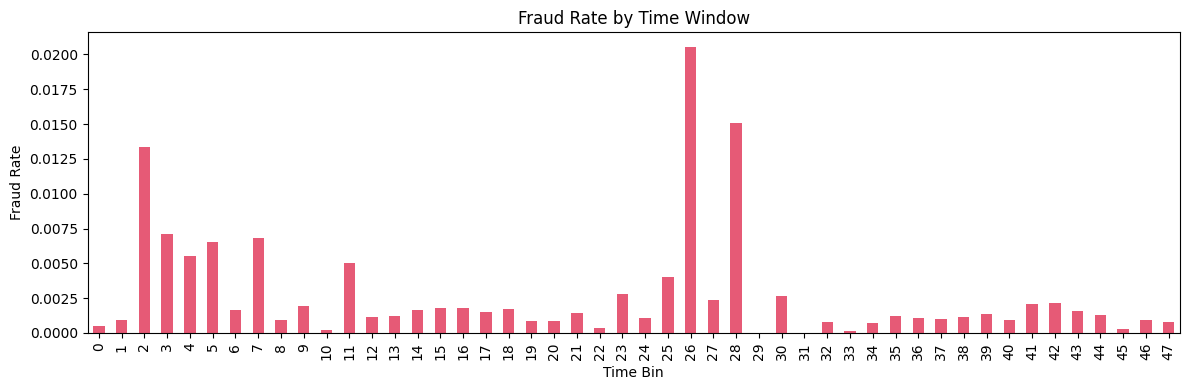

Max fraud rate in any bin: 0.0206
Min fraud rate in any bin: 0.0000
Overall fraud rate: 0.0017


In [35]:
df['time_bin'] = pd.cut(df['Time'], bins=48, labels=False)

fraud_rate = df.groupby('time_bin')['Class'].mean()

plt.figure(figsize=(12, 4))
fraud_rate.plot(kind='bar', color='crimson', alpha=0.7)
plt.title('Fraud Rate by Time Window')
plt.xlabel('Time Bin')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

print(f"Max fraud rate in any bin: {fraud_rate.max():.4f}")
print(f"Min fraud rate in any bin: {fraud_rate.min():.4f}")
print(f"Overall fraud rate: {df['Class'].mean():.4f}")

### PCA Analysis
To identify which features had the strongest connection to fraudulent activity, I calculated Cohen's d effect size for each PCA feature and sorted them in descending order. The top three features were then examined using density histograms and box plots, with density normalization applied to account for the class imbalance found in the previous notebook.

All three features showed significant overlap between the two classes, confirming there is no clean linear separator available. However, the box plots revealed that while the distributions overlap broadly, the centers of each class are meaningfully offset. This tells us that the signal exists but is subtle, and that the model will need to be non-linear to capture the boundary between classes given the available features.

In [38]:
def effect_size(feature):
    fraud = df[df["Class"] == 1][feature]
    normal = df[df["Class"] == 0][feature]
    pooled_std = np.sqrt(fraud.std() ** 2 + normal.std() ** 2) / 2

    return abs(fraud.mean() - normal.mean()) / pooled_std

scores = {col: effect_size(col) for col in df.columns if col not in ["Class", "Time"]}
sorted(scores.items(), key=lambda x: x[1], reverse=True)

[('V14', 3.1948156783428248),
 ('V4', 2.8472853675923697),
 ('V11', 2.661809134699867),
 ('V12', 2.6403120421976416),
 ('V10', 2.271309502246005),
 ('V16', 2.096470585570814),
 ('V3', 1.9411212182886604),
 ('V17', 1.9048837773059468),
 ('V9', 1.895692077571421),
 ('V2', 1.58084281020507),
 ('V7', 1.5277871332075879),
 ('V18', 1.4929470606086161),
 ('V1', 1.355540303960921),
 ('V6', 1.2255111575407616),
 ('V5', 1.1393512542695028),
 ('V19', 0.7834028261145958),
 ('V20', 0.4809524653526604),
 ('time_bin', 0.41831160007195806),
 ('V21', 0.3633035958201799),
 ('V24', 0.26477747558657),
 ('V27', 0.2383700307002685),
 ('V28', 0.2372915363476602),
 ('Amount', 0.18929599685974854),
 ('V8', 0.16577660632058192),
 ('V26', 0.15339523054265014),
 ('V13', 0.1473423713033628),
 ('V15', 0.1336806429573407),
 ('V25', 0.08721221440845651),
 ('V23', 0.047572522348774335),
 ('V22', 0.01694971996641706)]

In [24]:
df.corr()["Class"].sort_values(ascending=False)[:10]

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

In [25]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

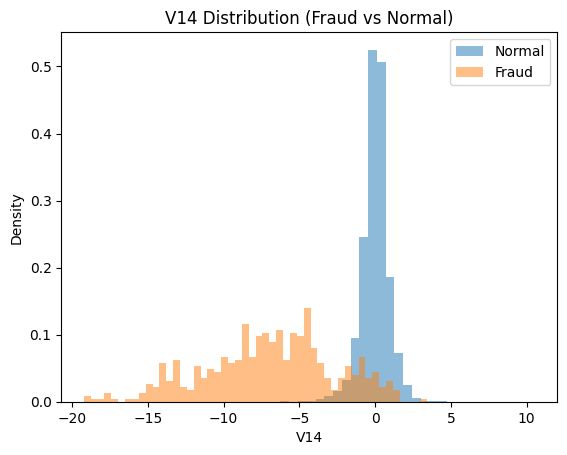

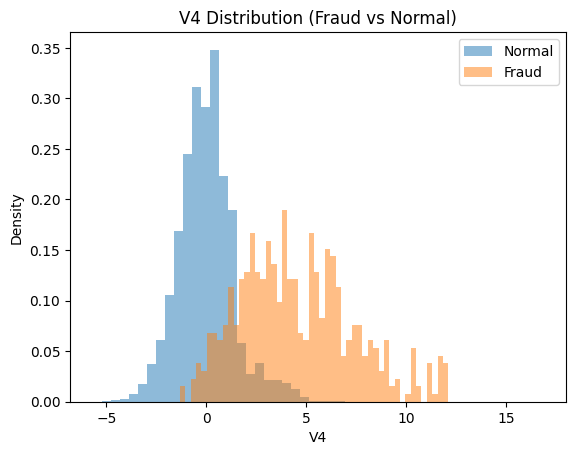

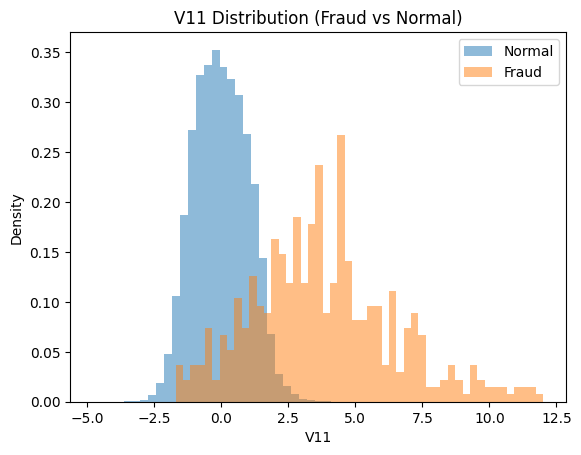

In [ ]:
features = ["V14", "V4", "V11"]

for feature in features:
    plt.figure()

    plt.hist(normal[feature], bins=50, alpha=0.5, density=True, label="Normal")
    plt.hist(fraud[feature], bins=50, alpha=0.5, density=True, label="Fraud")

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"{feature} Distribution (Fraud vs Normal)")
    plt.legend()

    plt.show()

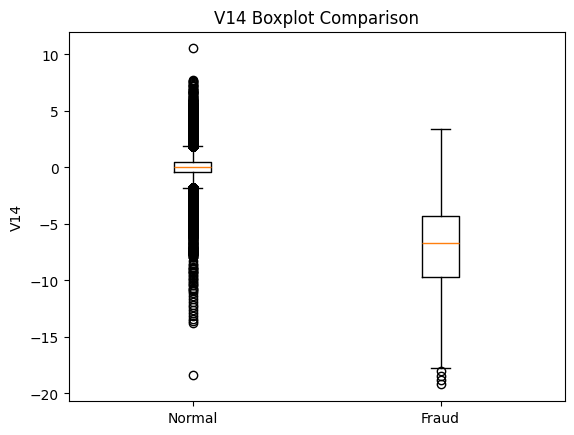

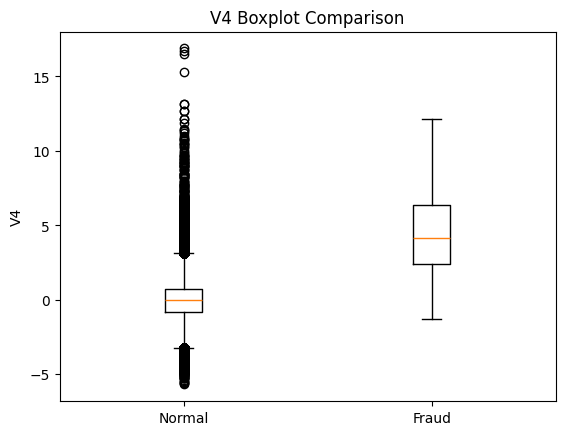

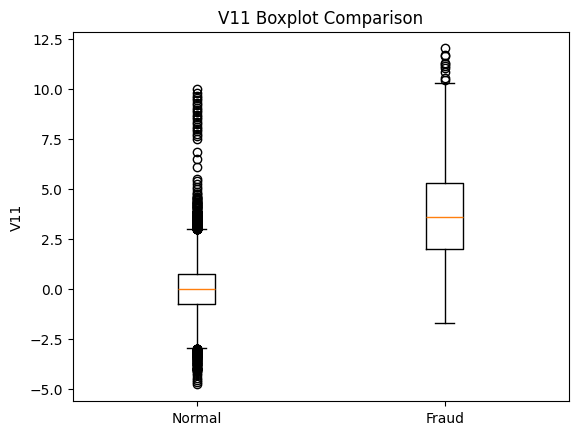

In [27]:
for feature in features:
    plt.figure()

    plt.boxplot(
        [normal[feature], fraud[feature]],
        tick_labels=["Normal", "Fraud"]
    )

    plt.title(f"{feature} Boxplot Comparison")
    plt.ylabel(feature)

    plt.show()

### PCA Feature Analysis (V14, V4, V11)

Normal transactions are tightly concentrated and approximately symmetric around zero, reflecting stable and consistent behavior in the transformed feature space. In contrast, fraudulent transactions display a broader and more dispersed distribution, often shifted toward negative values.

Histograms reveal that fraudulent transactions exhibit a multimodal structure, suggesting that fraud may arise from multiple underlying behavioral patterns rather than a single distribution.

Boxplot comparisons further highlight that fraudulent transactions have a significantly larger interquartile range, indicating greater variability.

### PCA Plots

Since no single feature provided clear class separation, I investigated further using multivariate feature spaces. Scatter plots were generated for all pairs of the three top-ranked features from the Cohen's d analysis. All three pairs told the same story: legitimate transactions remained tightly clustered while fraudulent transactions were broadly dispersed, with too much overlap to cleanly separate the two classes using any linear boundary. This led to the conclusion that a non-linear model would be necessary to capture the structure of fraud in this dataset.

In [28]:
normal = normal.sample(n=len(fraud)*5, random_state=42)

plot_df = pd.concat([fraud, normal])

def plot_pair(x,y):
    plt.figure()

    plt.scatter(
        plot_df[plot_df["Class"] == 0][x],
        plot_df[plot_df["Class"] == 0][y],
        alpha = 0.3,
        label = "Normal"
    )

    plt.scatter(
        plot_df[plot_df["Class"] == 1][x],
        plot_df[plot_df["Class"] == 1][y],
        alpha = 0.7,
        label = "Fraud"
    )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.legend()
    plt.show()

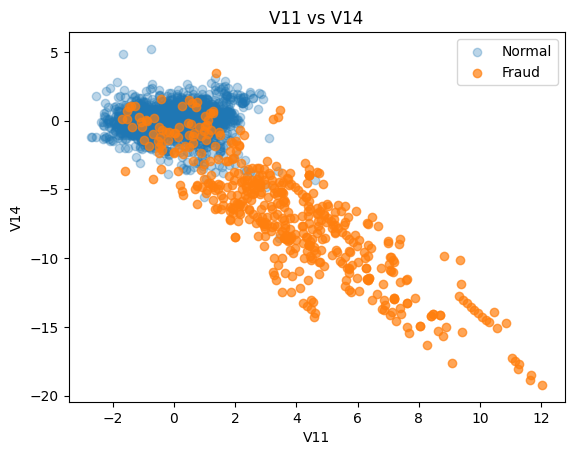

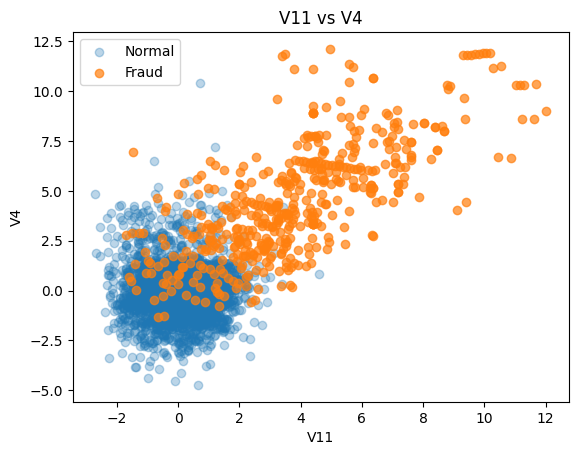

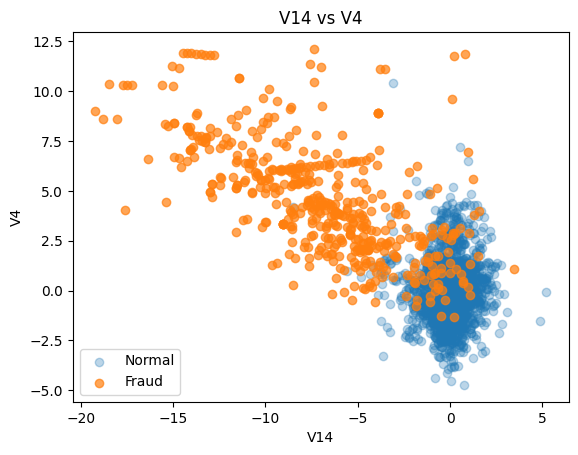

In [29]:
plot_pair("V11", "V14")
plot_pair("V11", "V4")
plot_pair("V14", "V4")

### Next Steps

The fraudulent and legitimate classes have distinct statistical characteristics: one is dispersed and messy, the other tight and clustered. Due to the overlap between these classes, I determined that a non-linear model will be best suited to capture the complex relationships within the data.

For preprocessing, I will start with StandardScaler and test RobustScaler as an iteration, given the outliers observed in the boxplot comparisons. For modeling, I will use Logistic Regression as an interpretable baseline and a tuned Random Forest as the non-linear model, comparing both to evaluate the precision-recall tradeoff.